In [17]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

# from src import Multicolour_Simulation_Functions

# MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

# from src import SpectralFunctions

# S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SupRes_F = SR_Functions.SuperRes_Functions()

import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

import DriftCorrectionFunctions as DCF


In [2]:
def getpixelefficiency(
    filename=os.path.abspath("../Spectra/Camera_QE/CS505CU_QE.csv"),
):
    """
    Gets pixel efficiency for a camera from a .csv file

    Args:
        filename (str): The name of the JSON file to load.

    Returns:
        R: red pixel QE
        G: green pixel QE
        B: blue pixel QE
    """
    data = pl.read_csv(filename)  # read data
    wavelength_coarse = data["wavelength"].to_numpy()  # read wavelength
    R_coarse = data["R"].to_numpy()  # read red
    G_coarse = data["G"].to_numpy()  # read green
    B_coarse = data["B"].to_numpy()  # read blue
    wavelength = np.arange(np.min(wavelength_coarse), np.max(wavelength_coarse))
    R = np.interp(x=wavelength, xp=wavelength_coarse, fp=R_coarse)
    G = np.interp(x=wavelength, xp=wavelength_coarse, fp=G_coarse)
    B = np.interp(x=wavelength, xp=wavelength_coarse, fp=B_coarse)
    return R, G, B, wavelength

In [3]:
data_folder = "../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [4]:
import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [5]:
image_folder = "/media/jbeckwith/Ezra Seagat/20251026_MassiveCells/Ximea/250pMATTO655_750pMCy3B_20perc561_60mW638_1/"
image_files = H_F.file_search(image_folder, ".tif", "")

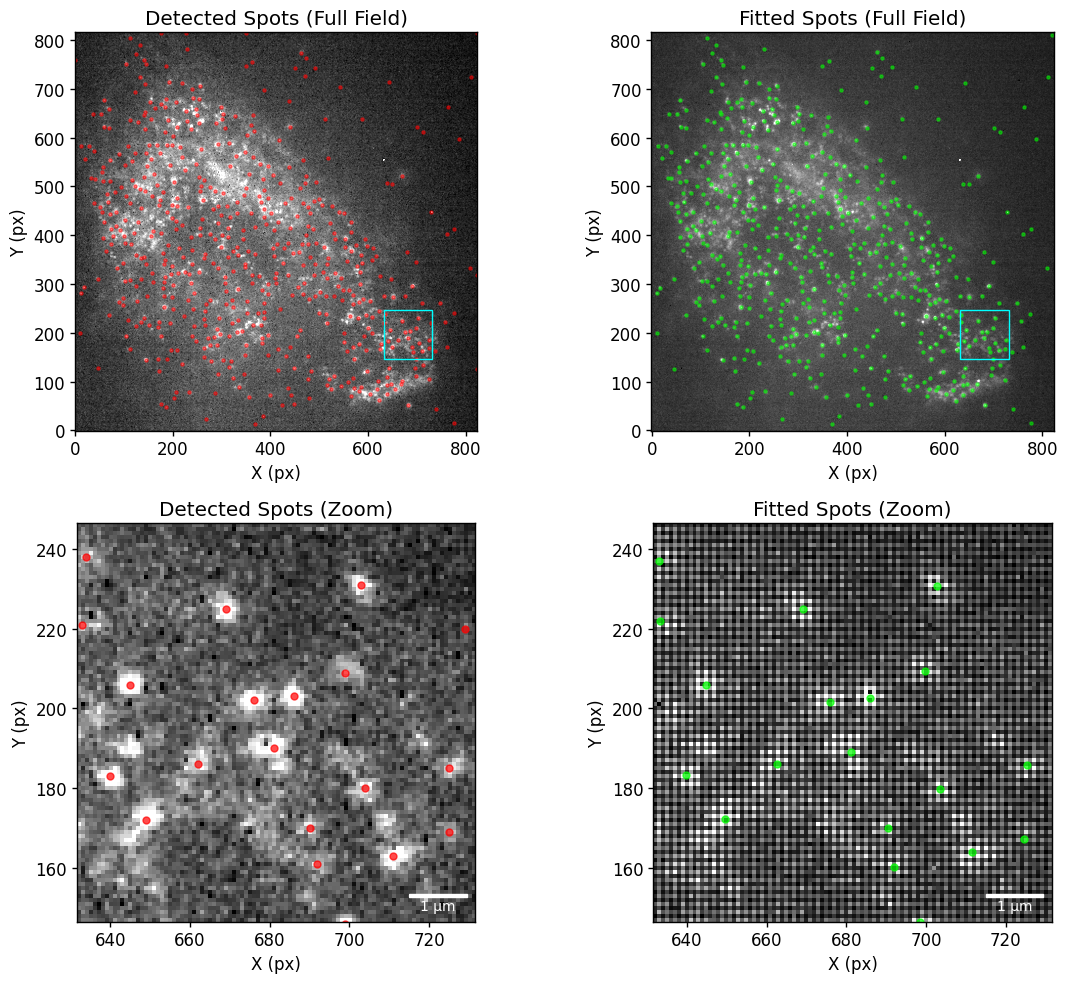

In [15]:
# play around with pfa to find a good parameter
fig, axs = SupRes_F.example_spots_singleframe(image_folder, pfa=1e-3, sigma=1.25, fraction_true=0.2, frame_index=200, variance=variance, read_noise=read_noise,
                                             rqe=rqe, offset_map=offset_map, gain_map=gain_map, peak_wavelength=0.6)
plt.show()

In [16]:
SupRes_F.fit_imaging_data(
    image_folder,
    smoothing_function,
    gain_map=gain_map,
    offset_map=offset_map,
    variance=variance,
    rqe=rqe,
    read_noise=read_noise,
    pfa=1e-3,
    ROI_size=12,
    peak_wavelength=0.6,
    sigma=1.25,
    fraction_true=0.2,
    NA=1.49,
    pixel_size=0.069,
    image_type=".tif",
)

Processing file 1/20: 3114 frames in chunks of 1000
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Processing chunk: frames 2000-2999                                            ?, ?it/s]
  Processing chunk: frames 3000-3113                                            ?, ?it/s]
  Found 1665738 puncta across all chunks                                        ?, ?it/s]
Processing file 2/20: 3114 frames in chunks of 1000                             ?, ?it/s]
  Processing chunk: frames 0-999
  Processing chunk: frames 1000-1999                                            ?, ?it/s]
  Processing chunk: frames 2000-2999                                            ?, ?it/s]
  Processing chunk: frames 3000-3113                                            ?, ?it/s]
  Found 1615365 puncta across all chunks                                        ?, ?it/s]
Sorting appended HDF5 file by frame: Localisations.h5                   